# Laboratorio de microcuentos en español: GPT, memoria y creatividad

**Mini-proyecto de generación de texto · Procesamiento del Lenguaje Natural**  
Cuenta del repositorio: **cris-bytes** · Caso propio: cinco universos de ficción breve.

### 1. Problema y alcance
Quien empieza a escribir suele necesitar una primera idea, no una historia terminada. Proponemos un
**asistente experimental de borradores**: recibe un tema y produce un microcuento; opcionalmente
recupera una primera frase del corpus para continuarla. La persona decide qué conservar y reescribir.
Una propuesta útil debería mantener un tema, formar frases comprensibles y evitar reproducir relatos enteros.

Un GPT causal es adecuado porque aprende $p(x_t\mid x_{<t},tema)$ y puede producir continuaciones nuevas.
Compararlo con un bigrama y una GRU permite preguntar si más contexto y atención justifican su coste.
La recuperación facilita un punto de partida concreto, aunque también puede favorecer la copia.

**Alcance honesto:** entrenamos desde cero un Transformer pequeño de tipo GPT, no un modelo de OpenAI
ni un asistente con conocimientos generales. El corpus es **sintético, redactado con asistencia de IA**:
60 plantillas narrativas y 16 variantes por plantilla. No representa la literatura en español ni equivale
a 960 relatos independientes. Las salidas son borradores experimentales, no cuentos de calidad garantizada.

### Relación con la sesión y aportes propios
Los [notebooks de Sesión 5](https://github.com/Ohtar10/icesi-nlp/tree/main/Sesion5) usan WikiHow,
Ollama y recuperación; expresamente no entrenan modelos. Aquí cambiamos tanto los datos como el problema
y añadimos entrenamiento para cubrir la rúbrica. Conservamos la separación **recuperador → contexto → generación**,
adaptada a un LM de continuación, y mostramos las fuentes del prefijo.

| Aspecto | Desarrollo de este caso |
|---|---|
| EDA | Longitudes, balance, léxico, cobertura BPE, duplicación y fuga por familias |
| Modelado | Bigrama suavizado, GRU, GPT de una y tres capas |
| Experimentos | Curvas, selección por validación, prueba reservada, temperatura, top-k y top-p |
| Innovación | Bootstrap por familias, auditoría de copia, BM25 y demo reproducible |
| Reproducibilidad | Datos locales, semillas, CPU, versiones y entrenamiento desde cero |

### Preguntas que contrastaremos
1. ¿Los modelos neuronales reducen la perplejidad respecto del bigrama en familias no vistas?
2. ¿Tres capas mejoran la generalización frente a una capa, con igual número de épocas y datos?
3. ¿Cambiar el muestreo aumenta diversidad a costa de coherencia o terminación?
4. ¿Recuperar un inicio aumenta la afinidad temática y el riesgo de copiar?

**Criterio técnico previo:** seleccionar checkpoints y arquitectura por menor NLL de validación.
La calidad narrativa se examina por separado; una menor perplejidad no demuestra creatividad.

### 2. Ejecución desde cero
Desde la raíz del repositorio: `python -m pip install -r requirements.txt`, abrir este notebook con ese
intérprete y ejecutar **Restart Kernel and Run All**. Alternativa: `python scripts/ejecutar_notebook.py`.
Se requiere Python 3.9–3.12 y aproximadamente unos minutos de CPU; el tiempo real se registra abajo.
No se necesitan claves, Ollama, GPU ni descargar modelos. Después de instalar dependencias, funciona sin red.
Las celdas entrenan de nuevo; no usan resultados guardados como sustituto del entrenamiento.
Los checkpoints se guardan localmente en `artifacts/`, pero no son necesarios para reproducir el trabajo.

In [1]:
from pathlib import Path
import os
ROOT = Path.cwd()
assert (ROOT / "data/familias.json").exists(), "Abra el notebook desde la raíz del repositorio."
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
(ROOT / "artifacts").mkdir(exist_ok=True)

In [2]:
import copy
import hashlib
import json
import math
import os
import platform
import random
import re
import time
from collections import Counter
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

SEED = 17
THEMES = ["memoria", "ciudad", "naturaleza", "tecnologia", "mar"]
SPECIAL = ["<pad>", "<bos>", "<eos>"] + [f"<{t}>" for t in THEMES]
PAD, BOS, EOS = 0, 1, 2

def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(4)
    torch.use_deterministic_algorithms(True)

def words(text):
    return re.findall(r"[a-záéíóúüñ]+", text.lower())

In [3]:
seed_all()
import importlib.metadata as metadata
runtime = {"python": platform.python_version(), "plataforma": platform.platform(),
           "semilla": SEED, "dispositivo": "cpu", "threads": torch.get_num_threads(),
           "versiones": {p: metadata.version(p) for p in ["torch", "numpy", "pandas", "tokenizers", "matplotlib"]}}
print(json.dumps(runtime, ensure_ascii=False, indent=2))
(ROOT / "artifacts/runtime.json").write_text(json.dumps(runtime, indent=2))

{
  "python": "3.9.6",
  "plataforma": "macOS-15.7.7-arm64-arm-64bit",
  "semilla": 17,
  "dispositivo": "cpu",
  "threads": 4,
  "versiones": {
    "torch": "2.8.0",
    "numpy": "2.0.2",
    "pandas": "2.3.3",
    "tokenizers": "0.22.2",
    "matplotlib": "3.9.4"
  }
}


271

### 3. Datos, procedencia y prevención de fuga
`data/familias.json` contiene los textos base originales de este ejercicio, redactados con ayuda de IA.
Cada relato tiene un inicio, una situación extraña y una resolución o imagen final. Se expanden únicamente
nombre, lugar y momento; **no se afirma que las variantes sean muestras independientes**.
Se conservaron tildes, puntuación y mayúsculas porque son parte de la escritura que queremos modelar.

La partición se decide por **familia**, estratificada por tema: 8 familias para entrenamiento, 2 para
validación y 2 para prueba en cada tema. Ninguna variante de una familia puede aparecer en otro conjunto.
Los motivos compartidos —cartas, ventanas, recuerdos— sí atraviesan conjuntos: la separación reduce la fuga
de plantillas, pero no garantiza independencia semántica. Esta limitación se conserva al interpretar resultados.

In [4]:
def build_corpus(root=Path(".")):
    """Separar familias ANTES de expandirlas evita fugas entre variantes."""
    families = json.loads((root / "data/familias.json").read_text())
    names = ["Ana", "Luis", "Luz", "Daniel", "Sara", "Tomás", "Elena", "Simón"]
    places = ["la plaza", "el parque", "el pueblo", "la estación"]
    moments = ["medianoche", "mediodía", "las seis", "las diez"]
    rows = []
    rng = np.random.default_rng(SEED)
    for theme in THEMES:
        order = rng.permutation(len(families[theme]))
        split_of = {int(i): ("train" if p < 8 else "val" if p < 10 else "test")
                    for p, i in enumerate(order)}
        for i, template in enumerate(families[theme]):
            for v in range(16):
                text = template.format(nombre=names[v % 8],
                                       lugar=places[(v // 4 + i) % 4],
                                       momento=moments[(v + i) % 4])
                rows.append(dict(id=f"{theme}-{i:02d}-{v:02d}",
                                 familia=f"{theme}-{i:02d}", tema=theme,
                                 split=split_of[i], texto=text,
                                 n_palabras=len(words(text))))
    df = pd.DataFrame(rows)
    assert len(df) == 960 and df.texto.nunique() == len(df)
    assert df.groupby("familia").split.nunique().max() == 1
    (root / "data").mkdir(exist_ok=True)
    df.to_csv(root / "data/microcuentos.csv", index=False)
    return df

def fit_tokenizer(df, root=Path(".")):
    """Byte BPE: aprende uniones solo con train; todo UTF-8 es representable."""
    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=768, special_tokens=SPECIAL,
                                  initial_alphabet=sorted(pre_tokenizers.ByteLevel.alphabet()),
                                  show_progress=False)
    tok.train_from_iterator(df.loc[df.split == "train", "texto"], trainer)
    (root / "artifacts").mkdir(exist_ok=True)
    tok.save(str(root / "artifacts/tokenizer.json"))
    for text in df.texto:
        assert tok.decode(tok.encode(text).ids) == text
    return tok

def encode_rows(df, tok):
    return [[BOS, tok.token_to_id(f"<{r.tema}>")] + tok.encode(r.texto).ids + [EOS]
            for r in df.itertuples()]

def make_batch(sequences, indices):
    rows = [sequences[int(i)] for i in indices]
    length = max(len(x) for x in rows) - 1
    x = torch.full((len(rows), length), PAD, dtype=torch.long)
    y = torch.full_like(x, PAD)
    for i, ids in enumerate(rows):
        x[i, :len(ids)-1] = torch.tensor(ids[:-1])
        y[i, :len(ids)-1] = torch.tensor(ids[1:])
        y[i, 0] = PAD  # No evaluar la etiqueta: es una condición dada.
    return x, y

In [5]:
df = build_corpus(ROOT)
display(df.groupby(["split", "tema"]).agg(relatos=("id", "size"), familias=("familia", "nunique")))
display(df.groupby("split").n_palabras.describe().round(1))
display(df.drop_duplicates("tema")[["tema", "texto"]].style.set_properties(**{"white-space": "normal"}))
print("Nulos:", int(df.isna().sum().sum()), "· duplicados exactos:", int(df.texto.duplicated().sum()))

relatos  familias
split tema                         
test  ciudad           32         2
      mar              32         2
      memoria          32         2
      naturaleza       32         2
      tecnologia       32         2
train ciudad          128         8
      mar             128         8
      memoria         128         8
      naturaleza      128         8
      tecnologia      128         8
val   ciudad           32         2
      mar              32         2
      memoria          32         2
      naturaleza       32         2
      tecnologia       32         2

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,160.0,40.6,1.5,37.0,40.0,41.0,42.0,43.0
train,640.0,40.9,1.6,37.0,40.0,41.0,42.0,45.0
val,160.0,40.6,1.6,38.0,39.8,40.5,41.2,44.0


,tema,texto
0,memoria,"Ana encontró una carta en la plaza. La letra era suya, pero la fecha pertenecía al día siguiente. Esperó hasta medianoche para abrirla. Dentro solo había una petición: no contestes. Por primera vez, dejó una carta sin respuesta."
192,ciudad,"Ana esperaba el último bus en la plaza. A medianoche llegó uno sin conductor y con todos los asientos ocupados por sombras. Subió porque reconoció la suya junto a la ventana. Durante el viaje, por primera vez, pudo descansar de seguirse."
384,naturaleza,"Ana sembró una semilla en la plaza. A medianoche apareció un árbol con hojas de papel. En cada hoja había una pregunta. Regó la tierra durante meses, pero nunca encontró respuestas. Finalmente se sentó bajo la sombra y dejó de buscarlas."
576,tecnologia,"Ana encendió un robot en la plaza. A medianoche, la máquina hizo su primera pregunta: para qué sirve esperar. Nadie encontró una respuesta en el manual. Al día siguiente, el robot seguía junto a la puerta, cuidando una planta que aún no había nacido."
768,mar,"Ana encontró una botella en la plaza. La abrió a medianoche y salió el sonido del mar. Dentro no había ningún mensaje. La dejó sobre la mesa para escucharla cada noche, hasta que una mañana apareció arena debajo de todas las puertas."


Nulos: 0 · duplicados exactos: 0


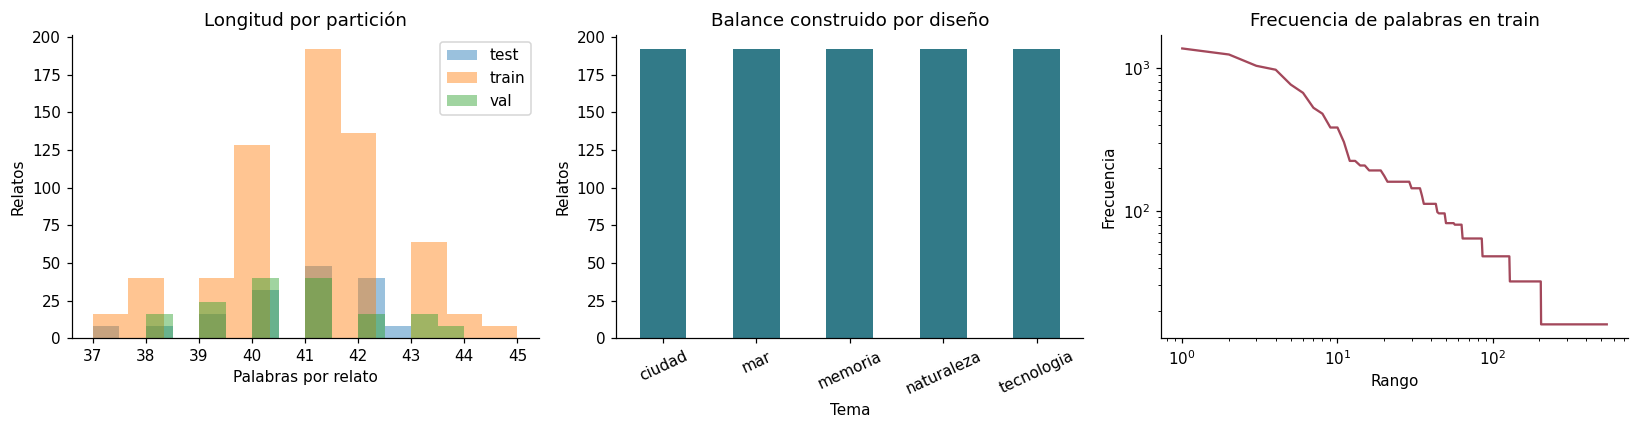

,palabra,frecuencia
0,la,1376
1,a,1248
2,el,1040
3,una,976
4,de,768
5,en,672
6,las,528
7,que,480
8,y,384
9,un,384


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for split, group in df.groupby("split"):
    ax[0].hist(group.n_palabras, bins=12, alpha=.45, label=split)
ax[0].set(xlabel="Palabras por relato", ylabel="Relatos", title="Longitud por partición")
ax[0].legend()
df.groupby("tema").size().plot.bar(ax=ax[1], color="#327a88", rot=25)
ax[1].set(title="Balance construido por diseño", ylabel="Relatos", xlabel="Tema")
counts = Counter(w for t in df[df.split == "train"].texto for w in words(t))
freqs = sorted(counts.values(), reverse=True)
ax[2].loglog(range(1, len(freqs)+1), freqs, color="#a3485b")
ax[2].set(xlabel="Rango", ylabel="Frecuencia", title="Frecuencia de palabras en train")
fig.tight_layout()
fig.savefig(ROOT / "artifacts/eda.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(counts.most_common(15), columns=["palabra", "frecuencia"]))

In [7]:
# Un split aleatorio por filas dejaría familias presentes en ambos lados.
perm = np.random.default_rng(SEED).permutation(len(df))
cut = int(.8*len(df))
random_train, random_eval = df.iloc[perm[:cut]], df.iloc[perm[cut:]]
leak_rate = random_eval.familia.isin(random_train.familia).mean()
real_overlap = set(df[df.split == "train"].familia) & set(df[df.split != "train"].familia)
assert not real_overlap
display(Markdown(f"**Hallazgo de EDA:** un split por filas compartiría familias en el **{leak_rate:.1%}** "
                "de las filas de evaluación. La partición por familias evita ese atajo. "
                f"Hay **{len(df)} variantes**, pero solo **{df.familia.nunique()} estructuras base**. "
                "El balance es artificial; no describe la frecuencia natural de los temas."))

**Hallazgo de EDA:** un split por filas compartiría familias en el **100.0%** de las filas de evaluación. La partición por familias evita ese atajo. Hay **960 variantes**, pero solo **60 estructuras base**. El balance es artificial; no describe la frecuencia natural de los temas.

### 4. Tokenización y diseño de la tarea
Usamos BPE de bytes con 768 tokens: aprende fragmentos frecuentes **solo de entrenamiento** y puede
representar texto UTF-8 desconocido sin convertir palabras de prueba en un token UNK.
La secuencia es `<bos> <tema> texto <eos>`. La etiqueta del tema es una condición conocida:
su predicción y el padding se excluyen de la pérdida. Sí se evalúa la predicción del fin del relato.
El vocabulario y los targets son iguales en todos los modelos, por lo que sus perplejidades son comparables.

In [8]:
tok = fit_tokenizer(df, ROOT)
encoded = {s: encode_rows(df[df.split == s], tok) for s in ["train", "val", "test"]}
df["tokens_bpe"] = [len(tok.encode(t).ids) for t in df.texto]
assert max(len(x) for rows in encoded.values() for x in rows) <= 256
display(df.groupby("split")[["n_palabras", "tokens_bpe"]].mean().round(2))
train_vocab = set(w for t in df[df.split == "train"].texto for w in words(t))
lexical_oov = {s: np.mean([w not in train_vocab for t in df[df.split == s].texto for w in words(t)])
               for s in ["val", "test"]}
print("Vocabulario BPE:", tok.get_vocab_size(), "· máxima longitud:", df.tokens_bpe.max())
print("Fracción de palabras no vistas (BPE sí las representa):", lexical_oov)
print("Ejemplo de segmentación:", tok.encode("Una brújula recordaba el mar.").tokens)
display(Markdown("**Decisión:** los relatos completos caben en 256 tokens; no se truncaron finales. "
                "Las palabras nuevas se descomponen en fragmentos, aunque poder representarlas no implica "
                "haber aprendido a utilizarlas. Los temas y variantes balanceados simplifican mucho la tarea."))

,n_palabras,tokens_bpe
split,,
test,40.60,83.0
train,40.92,73.2
val,40.60,83.5


Vocabulario BPE: 768 · máxima longitud: 97
Fracción de palabras no vistas (BPE sí las representa): {'val': np.float64(0.21428571428571427), 'test': np.float64(0.23399014778325122)}
Ejemplo de segmentación: ['U', 'na', 'Ġb', 'r', 'Ãº', 'j', 'u', 'la', 'Ġrecor', 'daba', 'Ġel', 'Ġmar', '.']


**Decisión:** los relatos completos caben en 256 tokens; no se truncaron finales. Las palabras nuevas se descomponen en fragmentos, aunque poder representarlas no implica haber aprendido a utilizarlas. Los temas y variantes balanceados simplifican mucho la tarea.

### 5. Arquitecturas y controles
El bigrama estima la transición entre dos tokens con suavizado aditivo $\alpha=0.1$; no tiene memoria larga.
La GRU mantiene un estado recurrente. El GPT usa embeddings de token y posición, atención causal multicefálica,
residuales, normalización y MLP. No utiliza encoder ni atención bidireccional.

La pérdida es $\mathcal L=-\sum_t\log p(x_t\mid x_{<t},tema)/N$ y la perplejidad es $\exp(\mathcal L)$.
Las capas GPT solo ven posiciones pasadas; el siguiente token aparece únicamente en el objetivo.
La tabla de parámetros muestra que la comparación **no iguala capacidad ni FLOPs**. La ablación de profundidad
mantiene ancho, datos, optimizador y épocas, pero cambia el número de parámetros.

In [9]:
class CausalBlock(nn.Module):
    def __init__(self, dim, heads, dropout):
        super().__init__()
        self.heads = heads
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.qkv, self.out = nn.Linear(dim, dim * 3), nn.Linear(dim, dim)
        self.ff = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(),
                                nn.Linear(4 * dim, dim), nn.Dropout(dropout))
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        b, t, d = x.shape
        q, k, v = self.qkv(self.ln1(x)).chunk(3, dim=-1)
        q, k, v = [z.view(b, t, self.heads, d // self.heads).transpose(1, 2)
                   for z in (q, k, v)]
        # La máscara causal impide consultar el token que se intenta predecir.
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.drop(self.out(a.transpose(1, 2).contiguous().view(b, t, d)))
        return x + self.ff(self.ln2(x))

class TinyGPT(nn.Module):
    def __init__(self, vocab, dim=96, layers=2, heads=4, context=256, dropout=.1):
        super().__init__()
        self.context = context
        self.emb = nn.Embedding(vocab, dim)
        self.pos = nn.Embedding(context, dim)
        self.blocks = nn.Sequential(*[CausalBlock(dim, heads, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, vocab)

    def forward(self, x):
        assert x.shape[1] <= self.context
        h = self.emb(x) + self.pos(torch.arange(x.shape[1]))
        return self.head(self.norm(self.blocks(h)))

class GRULM(nn.Module):
    def __init__(self, vocab, dim=128, context=256):
        super().__init__()
        self.context = context
        self.emb = nn.Embedding(vocab, dim)
        self.gru = nn.GRU(dim, dim, batch_first=True)
        self.head = nn.Linear(dim, vocab)

    def forward(self, x):
        h, _ = self.gru(self.emb(x))
        return self.head(h)

class BigramLM(nn.Module):
    """Baseline de conteos con suavizado; mismo vocabulario y targets."""
    def __init__(self, vocab, sequences, alpha=.1):
        super().__init__()
        self.context = 256
        counts = torch.full((vocab, vocab), alpha)
        for ids in sequences:
            for a, b in zip(ids[1:-1], ids[2:]):
                counts[a, b] += 1
        self.register_buffer("log_probs", (counts / counts.sum(1, keepdim=True)).log())

    def forward(self, x):
        return self.log_probs[x]

In [10]:
@torch.inference_mode()
def evaluate(model, sequences, batch_size=32):
    model.eval()
    rows = []
    for start in range(0, len(sequences), batch_size):
        x, y = make_batch(sequences, range(start, min(start+batch_size, len(sequences))))
        losses = F.cross_entropy(model(x).transpose(1, 2), y,
                                 ignore_index=PAD, reduction="none")
        for loss, target in zip(losses, y):
            rows.append({"nll_sum": float(loss.sum()), "tokens": int((target != PAD).sum())})
    result = pd.DataFrame(rows)
    result["nll"] = result.nll_sum / result.tokens
    return result

def global_nll(table):
    return float(table.nll_sum.sum() / table.tokens.sum())

CONFIGS = [
    {"name": "GRU-128", "kind": "gru", "dim": 128, "layers": 1, "lr": .002},
    {"name": "GPT-1c", "kind": "gpt", "dim": 96, "layers": 1, "lr": .002},
    {"name": "GPT-3c", "kind": "gpt", "dim": 96, "layers": 3, "lr": .002},
]

def train_experiments(encoded, vocab, root=Path("."), epochs=24):
    """Siempre entrena desde cero. Test no participa en selección ni parada."""
    all_models, histories, summaries = {}, [], []
    baseline = BigramLM(vocab, encoded["train"])
    all_models["Bigrama"] = baseline
    for config in CONFIGS:
        seed_all()
        if config["kind"] == "gru":
            model = GRULM(vocab, config["dim"])
        else:
            model = TinyGPT(vocab, config["dim"], config["layers"])
        optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=.01)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        best, best_state, best_epoch = float("inf"), None, 0
        rng = np.random.default_rng(SEED)
        started = time.perf_counter()
        for epoch in range(1, epochs+1):
            model.train()
            total_loss = total_tokens = 0
            indices = rng.permutation(len(encoded["train"]))
            for start in range(0, len(indices), 32):
                x, y = make_batch(encoded["train"], indices[start:start+32])
                optimizer.zero_grad(set_to_none=True)
                logits = model(x)
                loss = F.cross_entropy(logits.transpose(1, 2), y, ignore_index=PAD)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.)
                optimizer.step()
                count = int((y != PAD).sum())
                total_loss += float(loss.detach()) * count
                total_tokens += count
            val = global_nll(evaluate(model, encoded["val"]))
            histories.append(dict(modelo=config["name"], epoca=epoch,
                                  train_nll=total_loss/total_tokens, val_nll=val,
                                  lr=optimizer.param_groups[0]["lr"]))
            if val < best:
                best, best_state, best_epoch = val, copy.deepcopy(model.state_dict()), epoch
            scheduler.step()
            if epoch == 1 or epoch % 4 == 0:
                print(f'{config["name"]} época {epoch:02d}: train={total_loss/total_tokens:.3f}, val={val:.3f}', flush=True)
        if config["name"] == "GPT-3c":
            # Diagnóstico predefinido de sobreentrenamiento; no candidato al ranking principal.
            late = copy.deepcopy(model).eval()
            all_models["GPT-3c-final"] = late
            summaries.append(dict(modelo="GPT-3c-final", mejor_epoca=epochs,
                                  parametros=sum(p.numel() for p in late.parameters()),
                                  segundos=time.perf_counter()-started, val_nll=val,
                                  train_nll=global_nll(evaluate(late, encoded["train"]))))
            torch.save({"config": config, "state_dict": late.state_dict(), "vocab": vocab},
                       root / "artifacts/GPT-3c-final.pt")
        model.load_state_dict(best_state)
        model.eval()
        all_models[config["name"]] = model
        elapsed = time.perf_counter()-started
        summaries.append(dict(modelo=config["name"], mejor_epoca=best_epoch,
                              parametros=sum(p.numel() for p in model.parameters()), segundos=elapsed,
                              val_nll=best, train_nll=global_nll(evaluate(model, encoded["train"]))))
        torch.save({"config": config, "state_dict": best_state, "vocab": vocab},
                   root / "artifacts" / f'{config["name"]}.pt')
    summaries.append(dict(modelo="Bigrama", mejor_epoca=0, parametros=vocab*vocab,
                          segundos=0., val_nll=global_nll(evaluate(baseline, encoded["val"])),
                          train_nll=global_nll(evaluate(baseline, encoded["train"]))))
    history, summary = pd.DataFrame(histories), pd.DataFrame(summaries)
    history.to_csv(root / "artifacts/entrenamiento.csv", index=False)
    summary.to_csv(root / "artifacts/validacion.csv", index=False)
    return all_models, history, summary

def bootstrap_family(table, seed=SEED, n=1000):
    """Remuestrear familias, no variantes correlacionadas de un mismo relato."""
    grouped = table.groupby("familia")[["nll_sum", "tokens"]].sum().to_numpy()
    rng = np.random.default_rng(seed)
    samples = grouped[rng.integers(0, len(grouped), size=(n, len(grouped)))].sum(axis=1)
    return np.quantile(np.exp(samples[:, 0]/samples[:, 1]), [.025, .975])

In [11]:
@torch.inference_mode()
def generate(model, tok, theme, prompt="", temperature=.85, top_k=40,
             top_p=.95, seed=17, max_new_tokens=130):
    if theme not in THEMES:
        raise ValueError(f"Tema debe pertenecer a {THEMES}")
    if temperature <= 0 or not 0 < top_p <= 1 or top_k < 0:
        raise ValueError("Temperatura > 0, top_p en (0,1], top_k >= 0")
    model.eval()
    ids = [BOS, tok.token_to_id(f"<{theme}>")] + tok.encode(prompt).ids
    if len(ids) + max_new_tokens > model.context:
        raise ValueError("Reduce prompt o max_new_tokens para no exceder el contexto")
    first = len(ids)
    rng = torch.Generator().manual_seed(seed)
    finished = False
    for _ in range(max_new_tokens):
        logits = model(torch.tensor([ids]))[0, -1] / temperature
        eos_logit = logits[EOS].clone()
        logits[:len(SPECIAL)] = -float("inf")
        # EOS es el único token especial que puede ser generado.
        logits[EOS] = eos_logit if len(ids)-first >= 12 else -float("inf")
        if top_k:
            logits[logits < torch.topk(logits, min(top_k, len(logits))).values[-1]] = -float("inf")
        sorted_logits, indices = torch.sort(logits, descending=True)
        cumulative = torch.softmax(sorted_logits, -1).cumsum(-1)
        remove = cumulative > top_p
        remove[1:] = remove[:-1].clone()
        remove[0] = False
        logits[indices[remove]] = -float("inf")
        nxt = int(torch.multinomial(torch.softmax(logits, -1), 1, generator=rng))
        ids.append(nxt)
        if nxt == EOS:
            finished = True
            break
    continuation = tok.decode(ids[first:])
    return dict(texto=prompt+continuation, continuacion=continuation, eos=finished,
                tokens_nuevos=len(ids)-first)

def ngrams(text, n):
    ws = words(text)
    return [tuple(ws[i:i+n]) for i in range(len(ws)-n+1)]

def generation_metrics(text, train_texts, theme):
    ws = words(text)
    bigrams = ngrams(text, 2)
    lexicon = {
        "memoria": {"recuerdo", "recuerdos", "carta", "infancia", "fotografía", "reloj", "olvidado"},
        "ciudad": {"ciudad", "bus", "calle", "calles", "barrio", "edificios", "ventana"},
        "naturaleza": {"árbol", "semilla", "río", "bosque", "flores", "jardín", "hoja"},
        "tecnologia": {"robot", "máquina", "pantalla", "servidor", "teléfono", "código", "digital"},
        "mar": {"mar", "agua", "barcos", "barco", "faro", "ola", "isla", "océano"},
    }
    reference = set(g for t in train_texts for g in ngrams(t, 5))
    five = ngrams(text, 5)
    candidates = [set(ngrams(t, 3)) for t in train_texts]
    tri = set(ngrams(text, 3))
    nearest = max((len(tri & c)/max(1, len(tri | c)) for c in candidates), default=0.)
    return dict(palabras=len(ws), distinct2=len(set(bigrams))/max(1, len(bigrams)),
                copia5=sum(g in reference for g in five)/max(1, len(five)),
                jaccard_max=nearest, tema_lexico=float(bool(set(ws) & lexicon[theme])))

def demo(model, tok, retriever, tema="mar", idea="una carta junto al mar", recuperar=True,
         temperature=.85, seed=17):
    docs = retriever.search(idea, k=1) if recuperar else pd.DataFrame()
    # Adaptación de RAG a un LM de continuación: prefijo literario, no instrucciones.
    prefix = ""
    if len(docs):
        prefix = docs.iloc[0].texto.split(".", 1)[0] + "."
    out = generate(model, tok, tema, prefix, temperature=temperature, seed=seed)
    out["prefijo_recuperado"] = prefix
    out["fuentes"] = docs[["id", "familia", "score"]].to_dict("records") if len(docs) else []
    return out

In [12]:
# Verificación de causalidad: cambiar el sufijo no debe alterar predicciones del prefijo.
seed_all()
untrained = TinyGPT(tok.get_vocab_size(), layers=1).eval()
x = torch.tensor([encoded["train"][0][:-1]])
changed = x.clone()
changed[:, 12:] = (changed[:, 12:]+1) % tok.get_vocab_size()
with torch.no_grad():
    assert torch.allclose(untrained(x)[:, :12], untrained(changed)[:, :12], atol=1e-6)
print("Máscara causal verificada.")
print("GPT antes de entrenar:", generate(untrained, tok, "mar", max_new_tokens=45)["texto"])
display(pd.DataFrame(CONFIGS))

Máscara causal verificada.
GPT antes de entrenar:  vac�<ntana pi� quiso al�E Sara�tosntóuesta alcó ciudad cuiriquina amano sile�8� rri su iniscen recor�ntallaTomás pu[ voñana buesta im


,name,kind,dim,layers,lr
0,GRU-128,gru,128,1,0.002
1,GPT-1c,gpt,96,1,0.002
2,GPT-3c,gpt,96,3,0.002


### 6. Entrenamiento real y selección por validación
Entrenamos 24 épocas, lotes de 32 relatos, AdamW, decaimiento de pesos 0.01, recorte de gradiente a 1
y aprendizaje inicial 0.002 con descenso coseno. En GPT usamos dropout 0.1. Todos reciben los mismos relatos
y el mismo orden de lotes. Guardamos el checkpoint con menor NLL de validación de cada modelo.
Una sola semilla de entrenamiento permite una comparación reproducible, pero no estima la variabilidad
entre inicializaciones; las semillas de generación posteriores no sustituyen ese experimento.

In [13]:
models_trained, history, validation = train_experiments(encoded, tok.get_vocab_size(), ROOT, epochs=24)
primary_validation = validation[validation.modelo != "GPT-3c-final"]
best_name = primary_validation.sort_values("val_nll").iloc[0].modelo
best_gpt_name = primary_validation[primary_validation.modelo.str.startswith("GPT")].sort_values("val_nll").iloc[0].modelo
best_gpt = models_trained[best_gpt_name]
display(validation.sort_values("val_nll").round(4))
print("Ganador por validación:", best_name, "· GPT para la demo:", best_gpt_name)

GRU-128 época 01: train=5.881, val=5.227


GRU-128 época 04: train=2.868, val=4.451


GRU-128 época 08: train=0.976, val=4.763


GRU-128 época 12: train=0.439, val=5.187


GRU-128 época 16: train=0.305, val=5.487


...

GPT-3c época 16: train=0.112, val=6.539


GPT-3c época 20: train=0.107, val=6.600


GPT-3c época 24: train=0.106, val=6.603


,modelo,mejor_epoca,parametros,segundos,val_nll,train_nll
0,GRU-128,5,296448,12.8606,4.4494,1.8857
3,GPT-3c,3,508512,20.1292,4.6995,2.0927
1,GPT-1c,3,284832,9.5095,4.7636,2.8916
4,Bigrama,0,589824,0.0000,4.9843,2.4301
2,GPT-3c-final,24,508512,19.8589,6.6025,0.0952


Ganador por validación: GRU-128 · GPT para la demo: GPT-3c


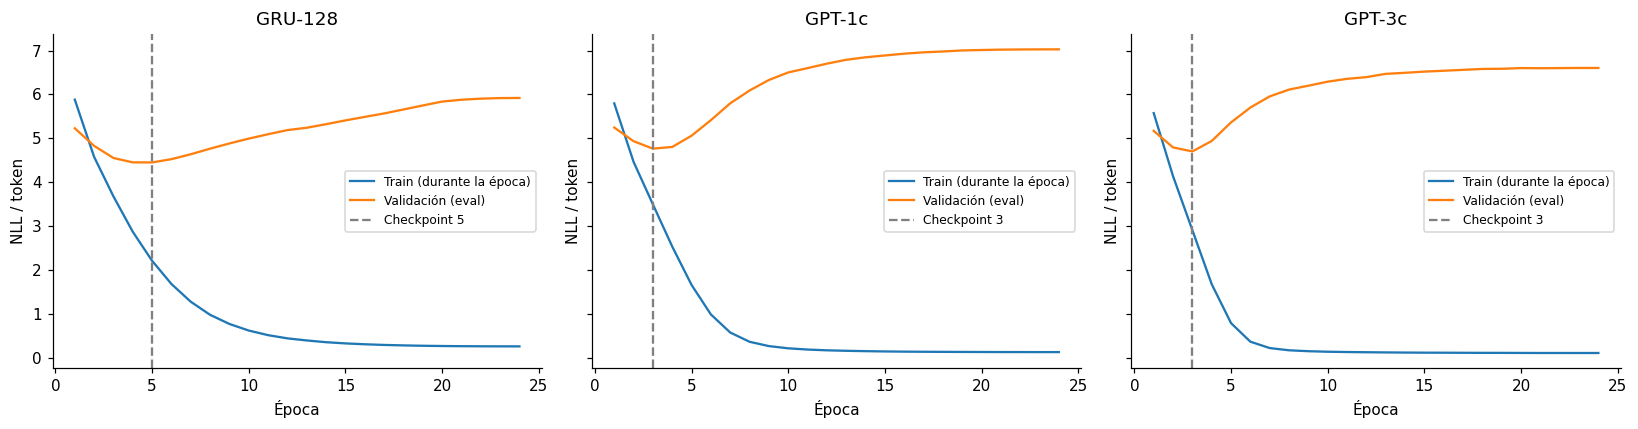

,modelo,mejor_epoca,train_nll,val_nll,brecha
0,GRU-128,5,1.886,4.449,2.564
1,GPT-1c,3,2.892,4.764,1.872
2,GPT-3c-final,24,0.095,6.603,6.507
3,GPT-3c,3,2.093,4.699,2.607
4,Bigrama,0,2.430,4.984,2.554


**Lectura:** se eligió **GRU-128** por validación. Una pérdida de entrenamiento menor que la de validación es compatible con memorización de estructuras. La curva de train se mide durante las actualizaciones y con dropout; la tabla anterior reevalúa el checkpoint en modo eval, por eso las cifras no tienen que coincidir.

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, h) in zip(axs, history.groupby("modelo", sort=False)):
    ax.plot(h.epoca, h.train_nll, label="Train (durante la época)")
    ax.plot(h.epoca, h.val_nll, label="Validación (eval)")
    selected = int(validation[validation.modelo == name].mejor_epoca.iloc[0])
    ax.axvline(selected, ls="--", c="gray", label=f"Checkpoint {selected}")
    ax.set(title=name, xlabel="Época", ylabel="NLL / token")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "artifacts/curvas_entrenamiento.png", bbox_inches="tight")
plt.show()
gap = validation.assign(brecha=validation.val_nll-validation.train_nll)
display(gap[["modelo", "mejor_epoca", "train_nll", "val_nll", "brecha"]].round(3))
display(Markdown(f"**Lectura:** se eligió **{best_name}** por validación. Una pérdida de entrenamiento menor "
                "que la de validación es compatible con memorización de estructuras. "
                "La curva de train se mide durante las actualizaciones y con dropout; la tabla anterior "
                "reevalúa el checkpoint en modo eval, por eso las cifras no tienen que coincidir."))

### 7. Prueba reservada e incertidumbre
Solo después de fijar los checkpoints calculamos métricas de prueba. Reportamos NLL ponderada por tokens,
perplejidad e intervalos percentiles del 95% con 1.000 remuestreos de **familias completas**.
Diez familias de prueba son pocas: los intervalos reflejan sensibilidad al corpus, no incertidumbre por semilla
ni evidencia de superioridad universal. No cambiamos hiperparámetros a partir de esta tabla.

,modelo,mejor_epoca,parametros,segundos,val_nll,train_nll,test_nll,perplexity,ci_low,ci_high
0,GRU-128,5,296448,12.861,4.449,1.886,4.495,89.610,77.925,102.825
3,GPT-3c,3,508512,20.129,4.699,2.093,4.872,130.635,117.264,143.784
1,GPT-1c,3,284832,9.509,4.764,2.892,4.933,138.799,121.049,155.731
4,Bigrama,0,589824,0.000,4.984,2.430,5.130,168.971,142.962,199.191
2,GPT-3c-final,24,508512,19.859,6.603,0.095,6.860,953.003,767.955,1152.803


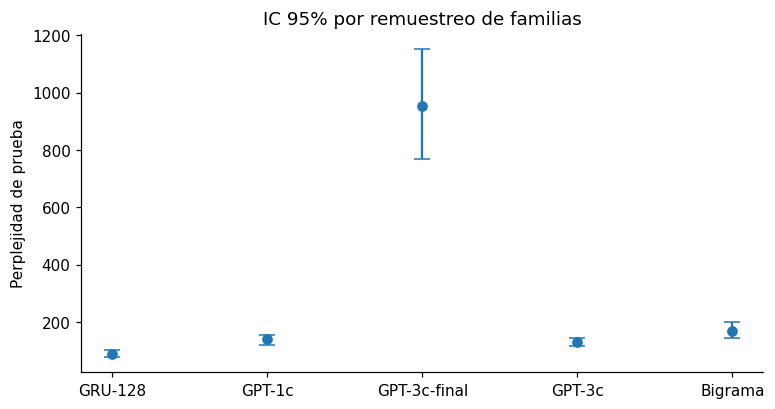

,Bigrama,GRU-128,GPT-1c,GPT-3c-final,GPT-3c
tema,,,,,
ciudad,214.44,114.08,171.34,1129.54,143.37
mar,174.17,87.14,122.08,821.45,129.73
memoria,174.56,85.23,132.29,1230.36,146.16
naturaleza,157.61,92.09,141.01,1089.64,126.55
tecnologia,136.40,75.19,132.80,655.62,112.11


In [15]:
test_meta = df[df.split == "test"].reset_index(drop=True)
test_tables, scores = {}, []
for name, model in models_trained.items():
    table = evaluate(model, encoded["test"])
    table["familia"], table["tema"] = test_meta.familia, test_meta.tema
    test_tables[name] = table
    nll = global_nll(table)
    low, high = bootstrap_family(table)
    scores.append(dict(modelo=name, test_nll=nll, perplexity=math.exp(nll), ci_low=low, ci_high=high))
results = validation.merge(pd.DataFrame(scores), on="modelo")
results.to_csv(ROOT / "artifacts/resultados.csv", index=False)
display(results.sort_values("val_nll").round(3))
fig, ax = plt.subplots(figsize=(8, 4))
r = results.set_index("modelo")
ax.errorbar(r.index, r.perplexity, yerr=[r.perplexity-r.ci_low, r.ci_high-r.perplexity], fmt="o", capsize=5)
ax.set(ylabel="Perplejidad de prueba", title="IC 95% por remuestreo de familias")
plt.show()
by_theme = pd.DataFrame({name: table.groupby("tema").apply(
    lambda g: math.exp(global_nll(g)), include_groups=False) for name, table in test_tables.items()})
display(by_theme.round(2))

### 8. Muestreo: temperatura, top-k y nucleus
Usamos el GPT seleccionado por validación. Temperatura divide los logits antes del softmax: valores bajos
concentran probabilidades. Top-k limita candidatos; top-p conserva una masa acumulada de probabilidad.
Comparamos configuraciones predefinidas para los cinco temas y dos semillas de generación. No escogemos
ejemplos por su apariencia. `distinct2` mide diversidad de bigramas dentro de cada salida; `copia5` es la
fracción de sus secuencias de cinco palabras que también aparecen en train. Esta última detecta coincidencias,
no plagio ni copia literal de un relato completo. La afinidad temática es un indicador léxico imperfecto.

,palabras,distinct2,copia5,jaccard_max,tema_lexico,eos
config,,,,,,
caliente,39.3,1.000,0.005,0.005,0.1,1.0
equilibrada,34.8,0.983,0.071,0.059,0.2,1.0
fría,29.7,0.968,0.157,0.082,0.2,1.0
nucleus,31.0,0.970,0.117,0.078,0.1,1.0


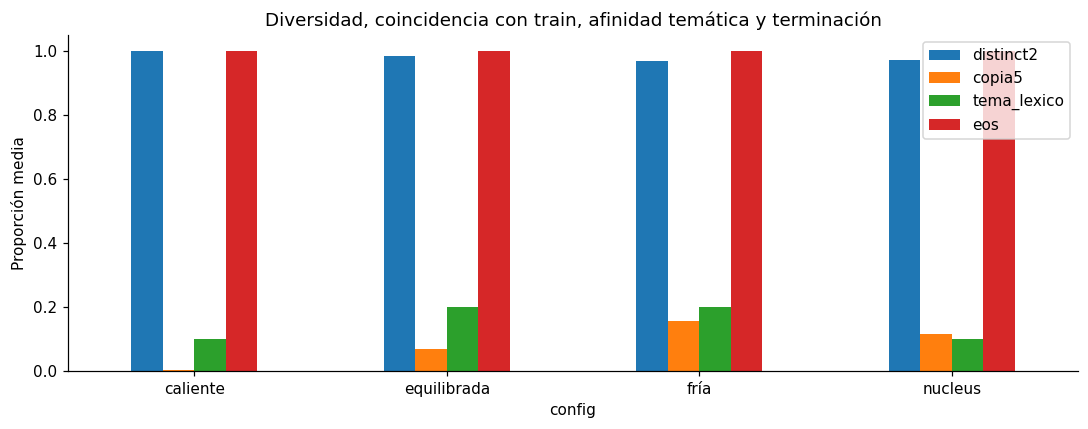

**fría · EOS=True**

En la plaza, Daniel repar una bormido en el parque. A las seis, la antas encontró una palabrase.

**equilibrada · EOS=True**

Elena la plaza, Daniel encontró una bormido en el pueblo. A las seis, la antas encontró una mingu.

**caliente · EOS=True**

! la si yeaban ver quiso al marer en el convers mañana� barcar rezaba su pregujaba sin se habían a r dem un in.cía, pequeña másn sucu cada llev bró despacioaronurantelamaba una sojaos de árboltaba fr nadie una el reco e�aba y No pudolenacidoas.

**nucleus · EOS=True**

Elena la plaza, Daniel encontró una bortos de el parque. A las diez, la se entas buscar la habían aano y un in cambi. isn en con cada vez, Elena. Aldo el parque.

In [16]:
train_texts = df[df.split == "train"].texto.tolist()
decoders_config = [
    {"config": "fría", "temperature": .55, "top_k": 20, "top_p": .9},
    {"config": "equilibrada", "temperature": .85, "top_k": 40, "top_p": .95},
    {"config": "caliente", "temperature": 1.15, "top_k": 0, "top_p": 1.},
    {"config": "nucleus", "temperature": .85, "top_k": 0, "top_p": .8},
]
generated = []
for cfg in decoders_config:
    for theme in THEMES:
        for seed in [17, 29]:
            output = generate(best_gpt, tok, theme, seed=seed,
                              **{k:v for k,v in cfg.items() if k != "config"})
            generated.append(dict(config=cfg["config"], tema=theme, seed=seed, **output,
                                  **generation_metrics(output["texto"], train_texts, theme)))
samples = pd.DataFrame(generated)
samples.to_csv(ROOT / "artifacts/generaciones.csv", index=False)
sampling_summary = samples.groupby("config")[["palabras", "distinct2", "copia5", "jaccard_max", "tema_lexico", "eos"]].mean()
display(sampling_summary.round(3))
sampling_summary[["distinct2", "copia5", "tema_lexico", "eos"]].plot.bar(figsize=(10, 4), rot=0)
plt.ylabel("Proporción media")
plt.title("Diversidad, coincidencia con train, afinidad temática y terminación")
plt.tight_layout()
plt.savefig(ROOT / "artifacts/muestreo.png", bbox_inches="tight")
plt.show()
for row in samples[(samples.tema == "mar") & (samples.seed == 17)].itertuples():
    display(Markdown(f"**{row.config} · EOS={row.eos}**\n\n{row.texto}"))

**Cómo interpretar:** un `distinct2` alto puede corresponder a palabras incoherentes; no es una puntuación
de calidad. La terminación EOS informa si el modelo cerró el relato antes del límite de tokens, no si el
final es satisfactorio. La comparación cambia algunos parámetros a la vez, por lo que describe recetas
de muestreo y no identifica el efecto causal aislado de cada parámetro. La siguiente ablación sí mantiene
top-k y top-p constantes al variar solo temperatura.

In [17]:
temperature_rows = []
for temp in [.55, .85, 1.15]:
    for theme in THEMES:
        out = generate(best_gpt, tok, theme, temperature=temp, top_k=40, top_p=.95, seed=43)
        temperature_rows.append(dict(temperatura=temp, tema=theme, **out,
                                     **generation_metrics(out["texto"], train_texts, theme)))
temperature_samples = pd.DataFrame(temperature_rows)
temperature_samples.to_csv(ROOT / "artifacts/ablacion_temperatura.csv", index=False)
display(temperature_samples.groupby("temperatura")[["distinct2", "copia5", "tema_lexico", "eos"]].mean().round(3))

,distinct2,copia5,tema_lexico,eos
temperatura,,,,
0.55,0.925,0.155,0.0,1.0
0.85,0.950,0.056,0.0,1.0
1.15,0.997,0.000,0.0,0.8


### Diagnóstico adicional: checkpoint temprano frente a entrenamiento prolongado
La selección por validación puede detenerse antes de que la generación suene fluida, especialmente con
solo 40 estructuras de entrenamiento. Conservamos también el GPT de tres capas de la época 24 como
**diagnóstico de memorización**, excluido de la selección principal. No se propone como ganador de generalización.
Comparamos el mejor checkpoint de esa misma arquitectura contra el final, con temas y semilla iguales.
Una salida más legible que copia train no prueba aprendizaje creativo ni mejora en familias nuevas.

In [18]:
late_rows = []
for name in ["GPT-3c", "GPT-3c-final"]:
    for theme in THEMES:
        out = generate(models_trained[name], tok, theme, temperature=.85, seed=17)
        late_rows.append(dict(modelo=name, tema=theme, **out,
                              **generation_metrics(out["texto"], train_texts, theme)))
late_samples = pd.DataFrame(late_rows)
late_samples.to_csv(ROOT / "artifacts/diagnostico_memorizacion.csv", index=False)
display(late_samples.groupby("modelo")[["distinct2", "copia5", "tema_lexico", "eos"]].mean().round(3))
for row in late_samples[late_samples.tema == "mar"].itertuples():
    display(Markdown(f"**{row.modelo}**\n\n{row.texto}"))

,distinct2,copia5,tema_lexico,eos
modelo,,,,
GPT-3c,0.967,0.071,0.4,1.0
GPT-3c-final,1.000,0.941,0.8,1.0


**GPT-3c**

Elena la plaza, Daniel encontró una bormido en el pueblo. A las seis, la antas encontró una mingu.

**GPT-3c-final**

En la plaza, Daniel reparaba barcos de papel a las seis. Un día llegó uno que había cruzado el océano. En su cubierta viajaba una palabra escrita con letra pequeña. La leyó en voz alta y recordó por qué había aprendido a esperar.

### 9. Recuperación y generación: adaptación del ejemplo de clase
Indexamos **solo las 40 familias de entrenamiento**, una variante por familia, con BM25. Su recuperación es
léxica: no entiende sinónimos como un encoder semántico. Por eso puede fallar incluso cuando existe un relato útil.
Evaluamos hit@1 y hit@3 **temáticos**, no relevancia humana ni recuperación de un documento exacto.

El GPT pequeño no fue entrenado para obedecer instrucciones de chat. Recuperamos la primera oración de
un relato y la usamos como prefijo para continuarlo. Es generación condicionada por texto recuperado,
inspirada en la organización de RAG de la sesión; **no reproduce el RAG original entrenado conjuntamente**.
Separamos prefijo reutilizado y continuación nueva, y mostramos la fuente del prefijo.

In [19]:
STOP = set("a al de del el la los las un una en que y su sus se por para con no lo como".split())

class BM25:
    def __init__(self, train_df, k1=1.5, b=.75):
        # Una variante por familia: no llenar top-k con casi duplicados.
        self.docs = train_df.drop_duplicates("familia").reset_index(drop=True)
        self.counts = [Counter(w for w in words(t) if w not in STOP) for t in self.docs.texto]
        self.lengths = np.array([sum(c.values()) for c in self.counts])
        self.avg = self.lengths.mean()
        self.df = Counter(w for c in self.counts for w in c)
        self.k1, self.b = k1, b

    def search(self, query, k=3):
        scores = np.zeros(len(self.docs))
        for w in set(words(query)) - STOP:
            freq = self.df.get(w, 0)
            idf = math.log(1 + (len(self.docs)-freq+.5)/(freq+.5))
            tf = np.array([c.get(w, 0) for c in self.counts])
            scores += idf * tf * (self.k1+1)/(tf+self.k1*(1-self.b+self.b*self.lengths/self.avg))
        order = np.argsort(-scores, kind="stable")[:k]
        return self.docs.iloc[order].assign(score=scores[order]).query("score > 0")

In [20]:
retriever = BM25(df[df.split == "train"])
queries = [
    ("memoria", "una carta con recuerdos de la infancia"),
    ("memoria", "una fotografía y el recuerdo de una casa"),
    ("ciudad", "un bus recorre las calles del barrio"),
    ("ciudad", "ventanas y edificios en una ciudad"),
    ("naturaleza", "un árbol crece junto al río"),
    ("naturaleza", "las flores y las semillas de un jardín"),
    ("tecnologia", "un robot aprende a hablar con una máquina"),
    ("tecnologia", "una pantalla y un servidor guardan mensajes"),
    ("mar", "un barco y una isla en el océano"),
    ("mar", "una carta llega con las olas del mar"),
]
retrieval_scores = []
for theme, query in queries:
    hits = retriever.search(query)
    retrieval_scores.append(dict(tema=theme, consulta=query,
        hit1=float(len(hits)>0 and hits.iloc[0].tema == theme), hit3=float(theme in hits.tema.values)))
retrieval_results = pd.DataFrame(retrieval_scores)
retrieval_results.to_csv(ROOT / "artifacts/recuperacion.csv", index=False)
display(retrieval_results)
print("Promedio:", retrieval_results[["hit1", "hit3"]].mean().to_dict())
display(retriever.search("una carta llega con las olas del mar")[["familia", "tema", "score", "texto"]])

,tema,consulta,hit1,hit3
0,memoria,una carta con recuerdos de la infancia,1.0,1.0
1,memoria,una fotografía y el recuerdo de una casa,0.0,1.0
2,ciudad,un bus recorre las calles del barrio,1.0,1.0
3,ciudad,ventanas y edificios en una ciudad,1.0,1.0
4,naturaleza,un árbol crece junto al río,1.0,1.0
5,naturaleza,las flores y las semillas de un jardín,1.0,1.0
6,tecnologia,un robot aprende a hablar con una máquina,1.0,1.0
7,tecnologia,una pantalla y un servidor guardan mensajes,1.0,1.0
8,mar,un barco y una isla en el océano,1.0,1.0
9,mar,una carta llega con las olas del mar,1.0,1.0


Promedio: {'hit1': 0.9, 'hit3': 1.0}


,familia,tema,score,texto
35,mar-06,mar,4.652030,Ana esperaba una carta frente al mar de el pue...
0,memoria-00,memoria,3.462546,Ana encontró una carta en la plaza. La letra e...
18,naturaleza-03,naturaleza,2.494562,"A las diez, Ana encontró un nido vacío en la e..."


In [21]:
# Evaluar SOLO la continuación: el prefijo recuperado es copia explícita por diseño.
retrieval_generations = []
for theme, query in queries:
    for retrieve in [False, True]:
        out = demo(best_gpt, tok, retriever, theme, query, retrieve, seed=17)
        retrieval_generations.append(dict(tema=theme, consulta=query, recuperacion=retrieve, **out,
            **generation_metrics(out["continuacion"], train_texts, theme)))
rag_samples = pd.DataFrame(retrieval_generations)
rag_samples.to_json(ROOT / "artifacts/demo_recuperacion.json", orient="records", force_ascii=False, indent=2)
display(rag_samples.groupby("recuperacion")[["distinct2", "copia5", "tema_lexico", "eos"]].mean().round(3))
example = rag_samples[(rag_samples.tema == "mar") & rag_samples.recuperacion].iloc[0]
print("Prefijo recuperado:", example.prefijo_recuperado)
print("Continuación generada:", example.continuacion)
print("Fuente del prefijo:", example.fuentes)

,distinct2,copia5,tema_lexico,eos
recuperacion,,,,
False,0.967,0.071,0.4,1.0
True,0.992,0.000,0.1,1.0


Prefijo recuperado: Ana dibujó una isla en la arena de la plaza.
Continuación generada:  A la piedra y la pare. or primera vez día siguiente, alcio una ciudad. Ant tibiado el mano. Cuando por cambi.
Fuente del prefijo: [{'id': 'mar-04-00', 'familia': 'mar-04', 'score': 3.184406212887002}]


**Límite del experimento:** sin recuperación, el modelo recibe solo el tema; con recuperación también recibe
el prefijo. Esta diferencia de información forma parte de la intervención. No demuestra que BM25 supere
a cualquier prefijo humano. Las dos consultas de un tema comparten la misma salida sin recuperación
con esta semilla; no son réplicas independientes. No calculamos significancia sobre esas filas duplicadas.
La fuente identifica material de inspiración y no verifica las afirmaciones ficticias generadas.

### 10. Demo editable
Cambie tema, idea, temperatura y semilla. La idea se utiliza para buscar el prefijo cuando `recuperar=True`;
sin recuperación, la condición del generador es únicamente el tema. Una consulta sin coincidencias devuelve
una lista de fuentes vacía y genera desde el tema.

In [22]:
MI_TEMA = "naturaleza"
MI_IDEA = "un árbol y una semilla junto al río"
MI_TEMPERATURA = .85
MI_SEMILLA = 29
mi_cuento = demo(best_gpt, tok, retriever, MI_TEMA, MI_IDEA,
                recuperar=True, temperature=MI_TEMPERATURA, seed=MI_SEMILLA)
display(Markdown("**Prefijo:** " + mi_cuento["prefijo_recuperado"]))
display(Markdown("**Continuación:** " + mi_cuento["continuacion"]))
print("Fuentes:", mi_cuento["fuentes"])
# Modo de contraste: mismo prefijo, checkpoint final susceptible de memorizar.
mi_cuento_final = demo(models_trained["GPT-3c-final"], tok, retriever, MI_TEMA, MI_IDEA,
                      recuperar=True, temperature=MI_TEMPERATURA, seed=MI_SEMILLA)
display(Markdown("**Contraste con época 24 (riesgo de memorización):** " + mi_cuento_final["continuacion"]))

**Prefijo:** En el parque, Ana escuchó cantar al río a mediodía.

**Continuación:**  P A medianoche llegó el pueblo, la pantallaabaasojabaonido.

Fuentes: [{'id': 'naturaleza-01-00', 'familia': 'naturaleza-01', 'score': 4.035114283409546}]


**Contraste con época 24 (riesgo de memorización):**  La melodía cambiaba cada vez que alguien arrojaba basura al agua. Aprendió a recoger lo que encontraba en la orilla. Un día el río pudo terminar la canción sin detenerse.

### 11. Hallazgos, límites y respuesta al problema
Las cifras siguientes se calculan de la ejecución actual. No se escribieron métricas ficticias ni se
rellenaron conclusiones antes de entrenar. La revisión cualitativa debe atender a continuidad de personajes,
concordancia, progresión de la situación y cierre; las métricas léxicas no capturan estos aspectos.

In [23]:
selected = results.set_index("modelo").loc[best_name]
bg = results.set_index("modelo").loc["Bigrama"]
improvement = 100*(1-selected.perplexity/bg.perplexity)
gpt_table = validation[validation.modelo.str.startswith("GPT")].set_index("modelo")
depth_message = ("tres capas obtuvieron menor NLL de validación" if gpt_table.loc["GPT-3c", "val_nll"] < gpt_table.loc["GPT-1c", "val_nll"]
                 else "una capa obtuvo menor o igual NLL de validación")
metrics_rag = rag_samples.groupby("recuperacion")[["copia5", "tema_lexico"]].mean()
conclusions = f'''**Resultados medidos**

- La selección por validación eligió **{best_name}**. Su perplejidad de prueba fue **{selected.perplexity:.2f}**
  frente a **{bg.perplexity:.2f}** del bigrama: una reducción relativa de **{improvement:.1f}%**.
  Su intervalo por familias fue **[{selected.ci_low:.2f}, {selected.ci_high:.2f}]**; no incorpora variación entre entrenamientos.
- En la ablación de profundidad, **{depth_message}**. Tener más parámetros no garantiza generalizar mejor;
  esta comparación mantiene épocas y datos, no coste computacional.
- La recuperación obtuvo hit@1 temático **{retrieval_results.hit1.mean():.0%}** en diez consultas manuales.
  La coincidencia de cinco palabras en la continuación pasó de **{metrics_rag.loc[False, "copia5"]:.1%}**
  sin recuperación a **{metrics_rag.loc[True, "copia5"]:.1%}** con recuperación. Son indicadores exploratorios,
  no una evaluación humana de relevancia o creatividad.
- El checkpoint final tiene una coincidencia media de cinco palabras de **{late_samples[late_samples.modelo == "GPT-3c-final"].copia5.mean():.1%}**
  en sus generaciones, frente a **{late_samples[late_samples.modelo == "GPT-3c"].copia5.mean():.1%}** del checkpoint temprano
  de la misma arquitectura. Se debe examinar si ganar fluidez significa reproducir las estructuras conocidas.
- El experimento aprendió patrones de un corpus pequeño, repetitivo y sintético. La separación por familias
  evita compartir la misma plantilla, pero los temas y el estilo fueron diseñados por una misma fuente.
  No es válido extrapolar estos resultados a cuentos de autores humanos ni a un producto editorial.

**Respuesta al problema:** la implementación funciona como laboratorio, pero las muestras del checkpoint seleccionado
presentan palabras deformadas, cambios de personaje y fragmentos sin conexión. **La utilidad como asistente literario
no queda demostrada**. Tener menor NLL que un bigrama y terminar con EOS no resuelve la coherencia narrativa.
El valor de recuperar una frase debe equilibrarse con su copia explícita y la posible continuación memorizada.

**Siguientes pasos:** reunir textos con permiso de uso de varios autores y separar por autor; repetir el entrenamiento
con al menos tres semillas; comparar BPE y un modelo preentrenado ajustado; hacer una evaluación ciega con lectores
que puntúen coherencia, sorpresa y utilidad; comparar recuperación frente a un prefijo humano de igual longitud.
'''
display(Markdown(conclusions))
(ROOT / "artifacts/conclusiones.md").write_text(conclusions)

**Resultados medidos**

- La selección por validación eligió **GRU-128**. Su perplejidad de prueba fue **89.61**
  frente a **168.97** del bigrama: una reducción relativa de **47.0%**.
  Su intervalo por familias fue **[77.92, 102.82]**; no incorpora variación entre entrenamientos.
- En la ablación de profundidad, **tres capas obtuvieron menor NLL de validación**. Tener más parámetros no garantiza generalizar mejor;
  esta comparación mantiene épocas y datos, no coste computacional.
- La recuperación obtuvo hit@1 temático **90%** en diez consultas manuales.
  La coincidencia de cinco palabras en la continuación pasó de **7.1%**
  sin recuperación a **0.0%** con recuperación. Son indicadores exploratorios,
  no una evaluación humana de relevancia o creatividad.
- El checkpoint final tiene una coincidencia media de cinco palabras de **94.1%**
  en sus generaciones, frente a **7.1%** del checkpoint temprano
  de la misma arquitectura. Se debe examinar si ganar fluidez significa reproducir las estructuras conocidas.
- El experimento aprendió patrones de un corpus pequeño, repetitivo y sintético. La separación por familias
  evita compartir la misma plantilla, pero los temas y el estilo fueron diseñados por una misma fuente.
  No es válido extrapolar estos resultados a cuentos de autores humanos ni a un producto editorial.

**Respuesta al problema:** la implementación funciona como laboratorio, pero las muestras del checkpoint seleccionado
presentan palabras deformadas, cambios de personaje y fragmentos sin conexión. **La utilidad como asistente literario
no queda demostrada**. Tener menor NLL que un bigrama y terminar con EOS no resuelve la coherencia narrativa.
El valor de recuperar una frase debe equilibrarse con su copia explícita y la posible continuación memorizada.

**Siguientes pasos:** reunir textos con permiso de uso de varios autores y separar por autor; repetir el entrenamiento
con al menos tres semillas; comparar BPE y un modelo preentrenado ajustado; hacer una evaluación ciega con lectores
que puntúen coherencia, sorpresa y utilidad; comparar recuperación frente a un prefijo humano de igual longitud.


2147

### 12. Trazabilidad y reproducibilidad
El manifiesto fija los datos y el vocabulario, configuración, semilla, checkpoint elegido y versiones.
CPU determinista y semillas controlan esta ejecución; entre sistemas, BLAS o versiones de PyTorch puede
haber pequeñas diferencias numéricas. Los tiempos de entrenamiento no son reproducibles como métricas exactas.
No se afirma haber validado todos los sistemas operativos. Las salidas adjuntas corresponden al entorno impreso.

In [24]:
manifest = {"runtime": runtime, "seed": SEED, "epochs": 24, "configs": CONFIGS,
            "best_validation": best_name, "best_gpt": best_gpt_name,
            "sha256": {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
                       for p in [ROOT/"data/familias.json", ROOT/"data/microcuentos.csv", ROOT/"artifacts/tokenizer.json"]}}
(ROOT / "artifacts/manifiesto.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
assert np.isfinite(results.test_nll).all()
assert all(len(set(df[df.split == a].familia) & set(df[df.split == b].familia)) == 0
           for a,b in [("train", "val"), ("train", "test"), ("val", "test")])
a = generate(best_gpt, tok, "mar", seed=123, max_new_tokens=25)
b = generate(best_gpt, tok, "mar", seed=123, max_new_tokens=25)
assert a == b, "La generación debe repetirse con la misma semilla."
print("Verificaciones finales: datos sin fuga de familias, métricas finitas y generación determinista.")
print("Artefactos guardados en", ROOT / "artifacts")

Verificaciones finales: datos sin fuga de familias, métricas finitas y generación determinista.
Artefactos guardados en /Users/cris/Desktop/MA_AI/Mini-Proyecto de generación de texto con GPT/artifacts


### Referencias y correspondencia con la rúbrica
- [Material de Sesión 5: RAG y LangChain](https://github.com/Ohtar10/icesi-nlp/tree/main/Sesion5).
- [Vaswani et al., Attention Is All You Need](https://arxiv.org/abs/1706.03762): atención y arquitectura Transformer.
- [Lewis et al., Retrieval-Augmented Generation](https://arxiv.org/abs/2005.11401): combinación de recuperación y generación.
- [Holtzman et al., The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751): nucleus sampling.
- [PyTorch: scaled dot product attention](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html).

| Criterio | Evidencia localizable |
|---|---|
| Notebook completo | Problema, EDA, código visible, entrenamiento, experimentos y conclusiones, §§1–12 |
| Reproducibilidad | Datos locales, versiones, semillas, ejecución limpia, hashes, §§2–4 y 12 |
| Modelo de generación | GPT causal entrenado, curvas, comparación y salidas, §§5–8 |
| Innovación | Split por familias, BPE, ablación, incertidumbre, copia, recuperación y demo, §§3–10 |

La tabla organiza evidencias; la calificación corresponde al docente. Se declara la asistencia de IA en
la redacción del corpus y en la implementación para que el grupo pueda explicar, revisar y defender cada decisión.